# **Mini EDA and Pipeline Design: Iris Dataset**

This notebook demonstrates a complete workflow for performing an Exploratory Data Analysis (EDA) and designing a preprocessing pipeline using Scikit-learn, based on the concepts from the previous notebooks.

## **1. Data Loading**

We will use the classic **Iris Dataset**, which contains 150 instances of iris flowers from three different species.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

# Load dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## **2. Mini EDA (Exploratory Data Analysis)**

### **2.1. Feature Exploration and Visualization**
Let's identify types of variables and visualize their relationships.

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


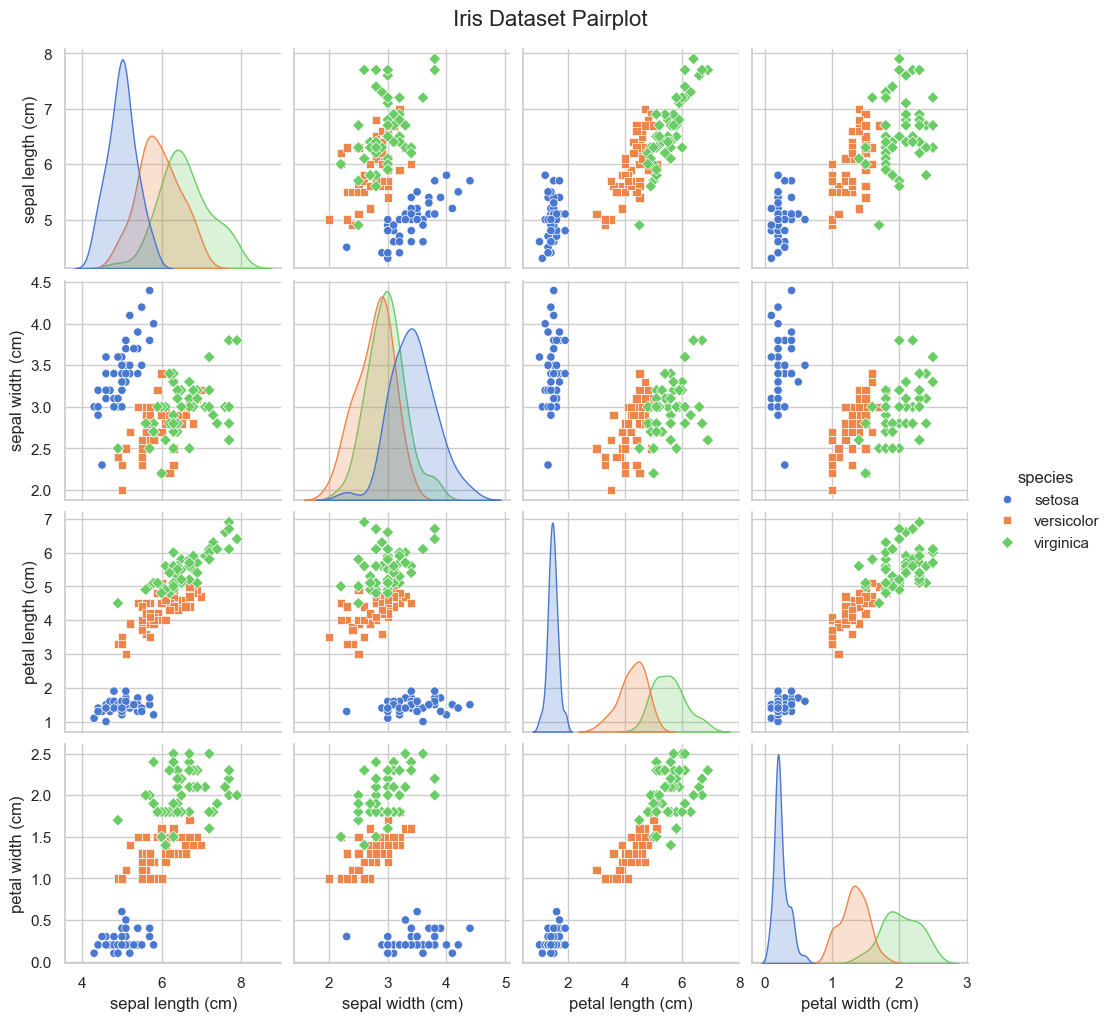

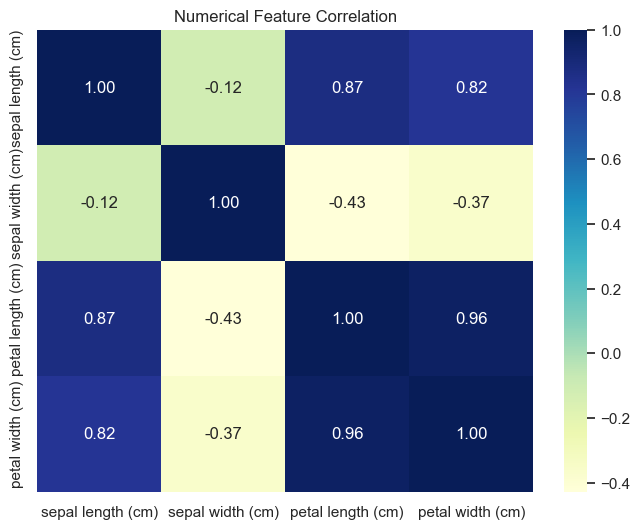

In [13]:
# Set visual style
sns.set_theme(style="whitegrid", palette="muted")

# Information about the dataset
print("--- Data Info ---")
df.info()

# Statistics for numerical features
print("\n--- Descriptive Statistics ---")
display(df.describe().T)

# Visualizing distributions and relationships
sns.pairplot(df, hue='species', markers=["o", "s", "D"])
plt.suptitle("Iris Dataset Pairplot", y=1.02, fontsize=16)
plt.show()

# Correlation Heatmap (only numerical)
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('species', axis=1).corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Numerical Feature Correlation")
plt.show()

### **2.2. Identifying Variable Types**

| Feature | Class | Sub-type | Rationale |
| :--- | :--- | :--- | :--- |
| **Sepal/Petal dims** | Numerical | Continuous | Measured values on a physical scale. |
| **Species** | Categorical | **Nominal** | Represents names without an inherent ranking. |

**Nominal vs Ordinal:**
- **Nominal:** Data like 'Species' (Setosa, Versicolor, Virginica). We use **One-Hot Encoding**.
- **Ordinal:** Data with a clear order (e.g., Seniority: Junior < Mid < Senior). We use **Ordinal Encoding**.

### **2.3. Missing Data Detection**
Before designing our pipeline, we must check for missing values.

In [14]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


**Decision on Imputation:** Although the Iris dataset typically has no missing values, in a real-world scenario, we would use an imputer:
- For **Numerical** data: Mean or Median imputation.
- For **Categorical** data: Mode (most frequent) imputation.

## **3. Pipeline Design**

We will structure a preprocessing pipeline that includes:
1. **Custom Feature Engineering:** A function to calculate the "Petal Area".
2. **Numerical Processing:** Imputation + Standardization.
3. **Categorical Processing:** Encoding (treated as a feature for demonstration).

In [15]:
# Defining custom function for Feature Engineering
def calculate_area(X):
    # Convert to numpy array to ensure indexing works correctly
    X_arr = np.asarray(X)
    # Assuming columns 2 and 3 are petal length and width
    petal_length = X_arr[:, [2]]
    petal_width = X_arr[:, [3]]
    return petal_length * petal_width

# Create transformer with validate=True to ensure conversion to NumPy
area_transformer = FunctionTransformer(calculate_area, validate=True)

# Define column groups
num_features = iris.feature_names
cat_features = ['species']

# 1. Numerical Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical Pipeline
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Combine in a ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
    ('area', area_transformer, num_features)
])

# Final Workflow
full_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

# Apply the pipeline
data_transformed = full_pipeline.fit_transform(df)
print(f"\nTransformed data shape: {data_transformed.shape}")
print("\nFirst row of transformed data:")
print(data_transformed[0])


Transformed data shape: (150, 8)

First row of transformed data:
[-0.90068117  1.01900435 -1.34022653 -1.3154443   1.          0.
  0.          0.28      ]


## **Summary of Transformations**

1. **SimpleImputer:** Ensured no NaN values interfere with calculations.
2. **StandardScaler:** Normalized numerical features to have mean 0 and variance 1.
3. **OneHotEncoder:** Converted the nominal `species` variable into binary columns.
4. **FunctionTransformer:** Engineered a new feature calculating petal area.